# Lagrange polynomials
Illustration of the Lagrange Polynomials connected to the Chebyshev Gauss-Lobatto collocation method

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import cos, sin, pi, tan

### Gauss-Lobatto points
Find the locations of the gauss-lobatto points on a grid of $N$ points (the higher-order polynomial is $N-1$)

Text(0.5, 0, '$\\xi$')

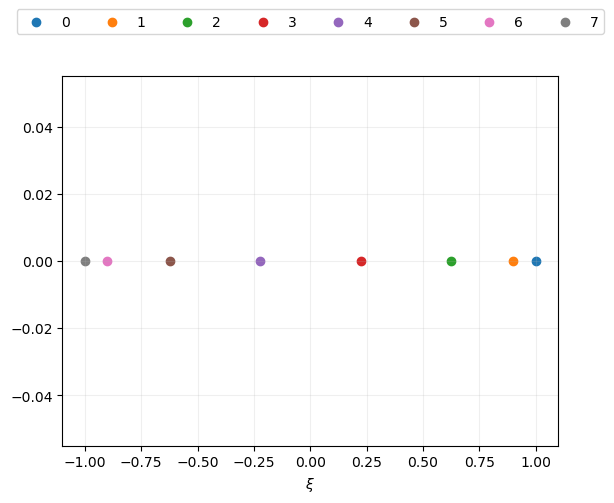

In [2]:
N = 8 # number of points
xi = np.array([cos(i*pi/(N-1)) for i in range(N)])

plt.figure()
i = 0
for x in xi:
    plt.scatter(x, 0, label='%i'%(i))
    i += 1
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=len(xi))
plt.grid(alpha=0.2)
plt.xlabel(r'$\xi$')

# Delta functions
Here we implement the discrete delta function $\psi_j(\xi_k) = \delta_{jk}$, and the polynomial representation 
$\psi_j = \prod_{j \neq k} \frac{\xi - \xi_k}{\xi_j - \xi_k}$, which are the Lagrange polynomial basis functions

Text(0.5, 0, '$\\xi$')

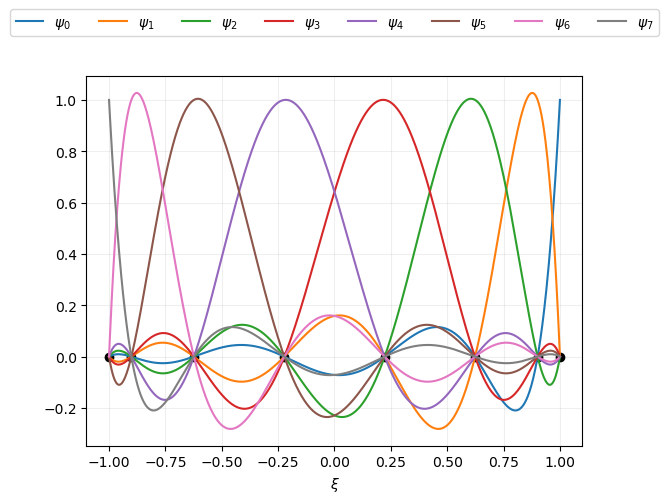

In [3]:
psi_disc = np.eye(N)

N_cnt = 1000
xi_cnt = np.linspace(1, -1, N_cnt)
psi_cont = np.zeros((N,N_cnt))
for j in range(N):
    prod = 1
    for k in range(N):
        if k!=j:
            prod *= (xi_cnt-xi[k])/(xi[j]-xi[k])
    psi_cont[j, :] = prod

plt.figure()
plt.plot(xi, xi*0, 'ko')
for j in range(N):
    plt.plot(xi_cnt, psi_cont[j,:], label=r'$\psi_{%i}$'%(j))
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=len(xi))
plt.grid(alpha=0.2)
plt.xlabel(r'$\xi$')

# Function approximation
Let's approximate now a function, projecting its values at the GL points on the Lagrange polynomials:
$f_N(\xi) = \sum_{j}f_j \psi_j(\xi)$, where $N$ denotes the N-points Lagrange interpolation of the function $f$.
The more complex the function is, the more points we'll need to approximate it adequately, but since it is an interpolation the values of the interpolation at the GL points must always be correct.

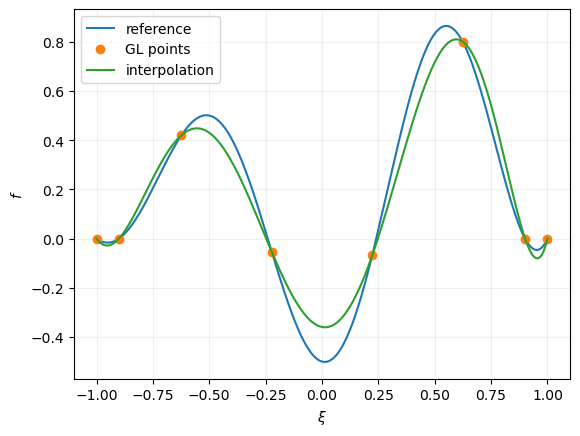

In [4]:
def general_function(x):
    return (cos(2*pi*x)-x**2)/(x-2)

f_cnt = general_function(xi_cnt) # reference function values
f_j = general_function(xi) # function values at gauss-lobatto points
f_interpolated = np.zeros(len(f_cnt))

for i in range(len(f_interpolated)):
    sum = 0
    for j in range(N):
        sum += f_j[j]*psi_cont[j,i]
    f_interpolated[i] = sum
    

plt.figure()
plt.plot(xi_cnt, f_cnt, label='reference')
plt.plot(xi, f_j, 'o', label='GL points')
plt.plot(xi_cnt, f_interpolated, label='interpolation')
plt.xlabel(r'$\xi$')
plt.ylabel(r'$f$')
plt.legend()
plt.grid(alpha=0.2)